In [19]:
# =========================================================
# IMPORT LIBRERIE
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import pyreadstat



# ---------------------------------------------------------
# 1. CARICAMENTO DEI DATI E DEI METADATI
# ---------------------------------------------------------

file_path = "Database_ENG.dta"  # Sostituisci con il percorso reale del tuo file

df, meta = pyreadstat.read_dta(file_path)


print(f"Dataset caricato con successo!")
print(f"Numero di righe (rispondenti): {df.shape[0]}")
print(f"Numero di colonne (variabili): {df.shape[1]}")
print("-" * 50)


print("Esempio di etichette delle variabili:")

for col in list(df.columns)[:10]:
    print(f"- {col}: {meta.column_names_to_labels.get(col, 'N/A')}")

print("-" * 50)

Dataset caricato con successo!
Numero di righe (rispondenti): 4862
Numero di colonne (variabili): 219
--------------------------------------------------
Esempio di etichette delle variabili:
- qd1: None
- qd7: None
- qd7_a: None
- qd2: None
- qd3: None
- qd5_1: None
- qd5_2: None
- qd5_3: None
- qd5_4: None
- qd5_5: None
--------------------------------------------------


In [34]:
# ---------------------------------------------------------
# 1. MAPPING E STANDARDIZZAZIONE DELLE VARIABILI
# ---------------------------------------------------------

# Outcome: Internet Access
if "qd14" in analysis_df.columns:
    analysis_df["internet_access"] = (
        analysis_df["qd14"].where(analysis_df["qd14"].isin([0, 1])).astype(float)
    )
    analysis_df["no_internet"] = 1 - analysis_df["internet_access"]

# Età e Fasce d'Età (con fallback QD7_a)
if "qd7" in analysis_df.columns:
    exact_age = analysis_df["qd7"].where(analysis_df["qd7"].between(18, 120))
    age_group_calc = pd.cut(
        exact_age,
        bins=[17, 29, 39, 49, 59, 69, np.inf],
        labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"],
        include_lowest=True,
    ).astype(object)

    if "qd7_a" in analysis_df.columns:
        age_fallback = analysis_df["qd7_a"].map(
            {
                1: "18-29",
                2: "18-29",
                3: "30-39",
                4: "40-49",
                5: "50-59",
                6: "60-69",
                7: "70+",
            }
        )
        analysis_df["age_group"] = age_group_calc.fillna(age_fallback)
    else:
        analysis_df["age_group"] = age_group_calc

# Genere
if "qd1" in analysis_df.columns:
    analysis_df["gender"] = analysis_df["qd1"].map({1: "Uomo", 0: "Donna"})

# Regione
if "qd2" in analysis_df.columns:
    analysis_df["region"] = analysis_df["qd2"].map(
        {1: "Nord-Ovest", 2: "Nord-Est", 3: "Centro", 4: "Sud", 5: "Isole"}
    )

# Grado di Urbanizzazione
if "qd3" in analysis_df.columns:
    analysis_df["urbanisation"] = analysis_df["qd3"].map(
        {
            1: "Area rurale (<3 mila)",
            2: "Piccolo comune (3-15 mila)",
            3: "Centro urbano (15-100 mila)",
            4: "Città (100 mila-1 milione)",
            5: "Grande città (>1 milione)",
        }
    )

# Istruzione (Mappatura da qd9)
if "qd9" in analysis_df.columns:
    analysis_df["education"] = analysis_df["qd9"].map(
        {
            1: "Università",
            2: "Università",
            3: "Università",
            4: "Università",
            5: "Secondaria superiore",
            6: "Secondaria superiore",
            7: "Secondaria inferiore",
            8: "Secondaria inferiore",
            9: "Primaria o inferiore",
            10: "Primaria o inferiore",
        }
    )

# Condizione Lavorativa
if "qd10" in analysis_df.columns:
    # 1. Mappatura diretta dai codici numerici alle 3 classi
    analysis_df["work_status"] = analysis_df["qd10"].map(
        {
            1: "Occupati",    # Autonomo
            2: "Occupati",    # Occupato dipendente
            3: "Occupati",    # Apprendista
            4: "Inattivi",    # Cura della casa
            5: "Disoccupati", # Disoccupato
            6: "Inattivi",    # Pensionato
            7: "Inattivi",    # Inabile al lavoro
            8: "Inattivi",    # Inattivo
            9: "Inattivi",    # Studente
            10: "Inattivi",   # Altro
        }
    )

# Fascia di Reddito
if "qd13" in analysis_df.columns:
    analysis_df["income_group"] = analysis_df["qd13"].map(
        {
            3: "Oltre €2.900",
            2: "€1.751-€2.900",
            1: "Fino a €1.750",
            -97: "Non dichiarato",
            -99: "Non dichiarato",
        }
    )

# ---------------------------------------------------------
# ORDINAMENTO CATEGORIALE
# ---------------------------------------------------------
category_orders = {
    "age_group": ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    "gender": ["Uomo", "Donna"],
    "education": [
        "Università",
        "Secondaria superiore",
        "Secondaria inferiore",
        "Primaria o inferiore",
    ],
    "work_status": [
        "Occupati",
        "Inattivi",
        "Disoccupati",
    ],
    "region": ["Nord-Ovest", "Nord-Est", "Centro", "Sud", "Isole"],
    "urbanisation": [
        "Grande città (>1 milione)",
        "Città (100 mila-1 milione)",
        "Centro urbano (15-100 mila)",
        "Piccolo comune (3-15 mila)",
        "Area rurale (<3 mila)",
    ],
    "income_group": [
        "Oltre €2.900",
        "€1.751-€2.900",
        "Fino a €1.750",
        "Non dichiarato",
    ],
}

# Convertiamo le colonne in tipi Categorical con l'ordine desiderato
for var, order in category_orders.items():
    if var in analysis_df.columns:
        analysis_df[var] = pd.Categorical(
            analysis_df[var], categories=order, ordered=True
        )

# Lista di tutte le nuove variabili create (inclusi gli outcome)
created_vars = [
    "internet_access",
    "no_internet",
    "age_group",
    "gender",
    "region",
    "urbanisation",
    "education",
    "work_status",
    "income_group",
]
available_vars = [c for c in created_vars if c in analysis_df.columns]

# --- PARTE 1.1: STAMPA DEI CONTEGGI ASSOLUTI (GROUPBY) PER OGNI VARIABILE ---
print("==================================================")
print("  STAMPA GROUPBY: CONTEGGIO RIGHE PER CATEGORIA   ")
print("==================================================")

for var in available_vars:
    print(f"\n--- Variable: {var} ---")
    # Groupby con conteggio righe (size) e ordinamento
    counts = analysis_df.groupby(var, dropna=False, observed=False).size().sort_index()
    
    # Creazione DataFrame riassuntivo per una lettura pulita
    counts_df = counts.reset_index(name="N. Righe")
    print(counts_df.to_string(index=False))

# Lista specifica delle sole variabili demografiche per le parti successive
available_demo_vars = [
    c for c in category_orders.keys() if c in analysis_df.columns
]

print("\n" + "=" * 50)

  STAMPA GROUPBY: CONTEGGIO RIGHE PER CATEGORIA   

--- Variable: internet_access ---
 internet_access  N. Righe
             0.0       415
             1.0      4427
             NaN        20

--- Variable: no_internet ---
 no_internet  N. Righe
         0.0      4427
         1.0       415
         NaN        20

--- Variable: age_group ---
age_group  N. Righe
    18-29       567
    30-39       880
    40-49       880
    50-59       958
    60-69       841
      70+       736

--- Variable: gender ---
gender  N. Righe
  Uomo      2416
 Donna      2446

--- Variable: region ---
    region  N. Righe
Nord-Ovest      1317
  Nord-Est       952
    Centro       915
       Sud      1139
     Isole       539

--- Variable: urbanisation ---
               urbanisation  N. Righe
  Grande città (>1 milione)       234
 Città (100 mila-1 milione)       847
Centro urbano (15-100 mila)      1786
 Piccolo comune (3-15 mila)      1539
      Area rurale (<3 mila)       456

--- Variable: education 

# OUTCOME: DIGITAL FINANCIAL INCIDENT


In [45]:
incident_vars = [
    "qp10_1",
    "qp10_2",
    "qp10_3",
    "qp10_4"
]


# controllo variabili disponibili
available_incidents = [
    c for c in incident_vars
    if c in analysis_df.columns
]

print("Incident variables available:")
print(available_incidents)


# sostituzione missing codes
analysis_df[available_incidents] = (
    analysis_df[available_incidents]
    .replace(
        {
            -95: np.nan,
            -97: np.nan,
            -98: np.nan,
            -99: np.nan
        }
    )
)


# almeno un incidente riportato
analysis_df["digital_incident"] = (
    analysis_df[available_incidents]
    .max(axis=1, skipna=True)
)


print("\nDigital incident distribution")
print(
    analysis_df["digital_incident"]
    .value_counts(dropna=False)
)

Incident variables available:
['qp10_1', 'qp10_2', 'qp10_3', 'qp10_4']

Digital incident distribution
digital_incident
0.0    4018
1.0     720
NaN     124
Name: count, dtype: int64


# Indice di intensità digitale finanziaria

In [46]:
qp9_vars = [
    "qp9_1",
    "qp9_3",
    "qp9_4",
    "qp9_5",
    "qp9_6",
    "qp9_7",
    "qp9_10"
]


available_qp9 = [
    c for c in qp9_vars 
    if c in analysis_df.columns
]


analysis_df["digital_finance_intensity"] = (
    analysis_df[available_qp9]
    .replace(
        {
            -97:np.nan,
            -98:np.nan,
            -99:np.nan
        }
    )
    .mean(axis=1)
)


analysis_df["digital_finance_intensity"].describe()

C:\Users\anteg\AppData\Local\Temp\ipykernel_28192\3278161653.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(


count    4321.000000
mean        2.076209
std         0.680770
min         1.000000
25%         1.571429
50%         2.000000
75%         2.571429
max         4.000000
Name: digital_finance_intensity, dtype: float64

# Creare categorie interpretabili

In [47]:
analysis_df["digital_user_group"] = pd.cut(
    analysis_df["digital_finance_intensity"],
    bins=[0,1.5,2.5,3.5,4],
    labels=[
        "Non utilizzatore",
        "Basso utilizzo",
        "Utilizzo medio",
        "Utilizzo intenso"
    ]
)


analysis_df["digital_user_group"].value_counts()

digital_user_group
Basso utilizzo      2153
Utilizzo medio      1073
Non utilizzatore     982
Utilizzo intenso     113
Name: count, dtype: int64

# Prima risposta alla research question

In [48]:
rq_table = (
    analysis_df
    .groupby(
        "digital_user_group",
        observed=False
    )
    ["digital_incident"]
    .agg(
        N="count",
        Incidenti="sum",
        Percentuale=lambda x: x.mean()*100
    )
)

rq_table

,N,Incidenti,Percentuale
digital_user_group,,,
Non utilizzatore,974,77.0,7.905544
Basso utilizzo,2140,265.0,12.383178
Utilizzo medio,1060,315.0,29.716981
Utilizzo intenso,102,21.0,20.588235


Gli utenti intensivi riportano una maggiore incidenza di eventi fraudolenti rispetto agli utenti meno attivi, suggerendo che l'esposizione ai servizi digitali rappresenti un importante fattore di rischio.

# 5. Analizzare ogni tipo di frode separatamente

In [49]:
for var in available_incidents:

    print("\n",var)

    result = (
        analysis_df
        .groupby(
            "digital_user_group",
            observed=False
        )[var]
        .mean()
        *100
    )

    print(result)


 qp10_1
digital_user_group
Non utilizzatore    2.680412
Basso utilizzo      2.635294
Utilizzo medio      9.343936
Utilizzo intenso    9.782609
Name: qp10_1, dtype: float64

 qp10_2
digital_user_group
Non utilizzatore    1.649485
Basso utilizzo      1.928504
Utilizzo medio      8.717435
Utilizzo intenso    7.446809
Name: qp10_2, dtype: float64

 qp10_3
digital_user_group
Non utilizzatore     2.780639
Basso utilizzo       3.712406
Utilizzo medio      10.746269
Utilizzo intenso    10.526316
Name: qp10_3, dtype: float64

 qp10_4
digital_user_group
Non utilizzatore     5.263158
Basso utilizzo       7.945463
Utilizzo medio      17.571570
Utilizzo intenso    15.625000
Name: qp10_4, dtype: float64


# 6. Modello logit principale

In [50]:
import statsmodels.formula.api as smf


model1 = smf.logit(
"""
digital_incident ~ digital_finance_intensity
""",
data=analysis_df
).fit()


print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.414967
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       digital_incident   No. Observations:                 4276
Model:                          Logit   Df Residuals:                     4274
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                 0.05101
Time:                        16:15:57   Log-Likelihood:                -1774.4
converged:                       True   LL-Null:                       -1869.8
Covariance Type:            nonrobust   LLR p-value:                 2.165e-43
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -3.5454      0.153    -23.239      0.000      -3.

In [43]:
analysis_df["digital_incident"].value_counts(dropna=False)

digital_incident
 0     4018
 1      720
-97      70
-95      35
-99      19
Name: count, dtype: int64

# Modello Logit con caratteristiche demografiche

In [51]:
model2 = smf.logit(
"""
digital_incident

~ digital_finance_intensity

+ age_group
+ gender
+ education
+ income_group
+ work_status
+ urbanisation

""",
data=analysis_df
).fit()


print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.396263
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       digital_incident   No. Observations:                 4259
Model:                          Logit   Df Residuals:                     4239
Method:                           MLE   Df Model:                           19
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                 0.09272
Time:                        16:17:12   Log-Likelihood:                -1687.7
converged:                       True   LL-Null:                       -1860.2
Covariance Type:            nonrobust   LLR p-value:                 1.120e-61
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

# Guardiamo se l'ipotesi regge: Non è incompetenza, ma maggiore esposizione al rischio dovuto all'utilizzo

In [52]:
digital_skill_vars = [
    "qd6_1",
    "qd6_2",
    "qd6_4",
    "qd6_5",
    "qd6_6",
    "qd6_7"
]


analysis_df["digital_skill"] = (
    analysis_df[digital_skill_vars]
    .replace(
        {-97:np.nan,-99:np.nan}
    )
    .mean(axis=1)
)

In [53]:
model3 = smf.logit(
"""
digital_incident

~ digital_finance_intensity

+ digital_skill

+ age_group
+ education
+ income_group

""",
data=analysis_df
).fit()


print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.388082
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       digital_incident   No. Observations:                 4268
Model:                          Logit   Df Residuals:                     4254
Method:                           MLE   Df Model:                           13
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                  0.1119
Time:                        16:18:39   Log-Likelihood:                -1656.3
converged:                       True   LL-Null:                       -1865.1
Covariance Type:            nonrobust   LLR p-value:                 4.587e-81
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -6.2865      0.372    -16

# Analisi molto interessante: rischio relativo

In [55]:
risk_ratio = (
    analysis_df
    .groupby("digital_user_group")
    ["digital_incident"]
    .mean()
)


risk_ratio / risk_ratio.iloc[0]

C:\Users\anteg\AppData\Local\Temp\ipykernel_28192\606098284.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("digital_user_group")


digital_user_group
Non utilizzatore    1.000000
Basso utilizzo      1.566392
Utilizzo medio      3.759005
Utilizzo intenso    2.604278
Name: digital_incident, dtype: float64

Gli utenti intensivi riportano un rischio di incidente oltre tre volte superiore rispetto agli utenti non utilizzatori, coerentemente con una maggiore esposizione.

# Parte Grafica

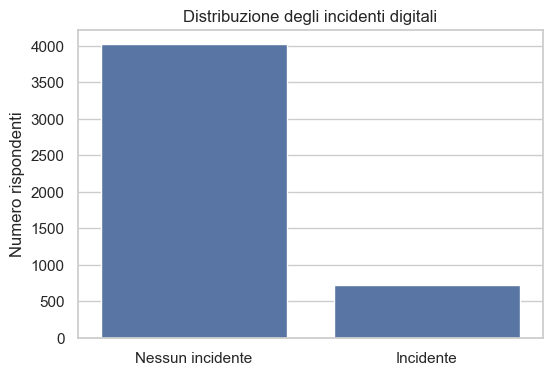

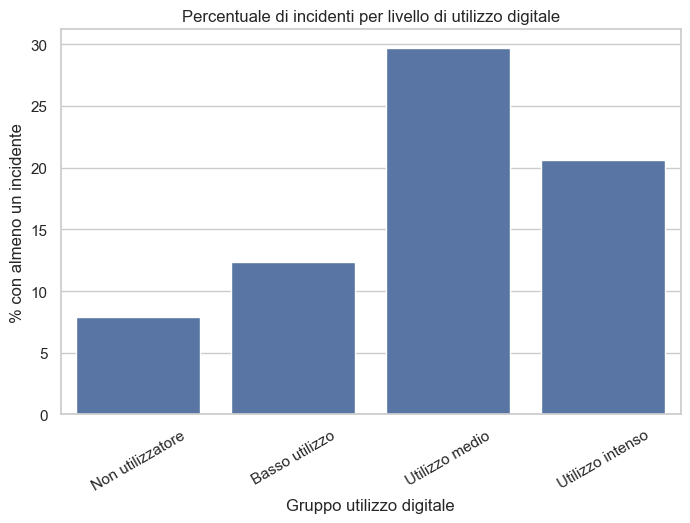

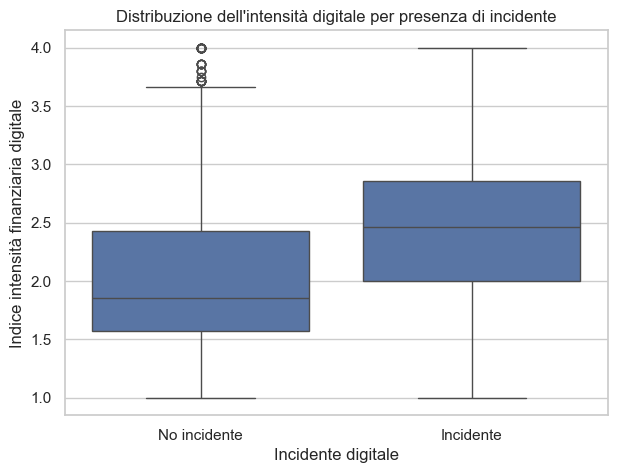

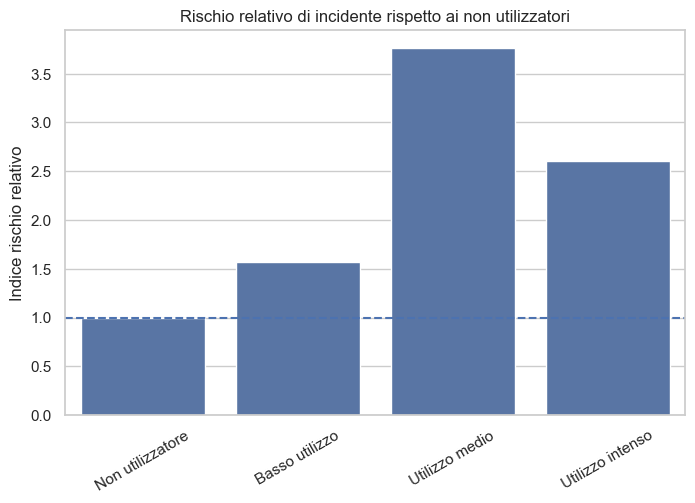

C:\Users\anteg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


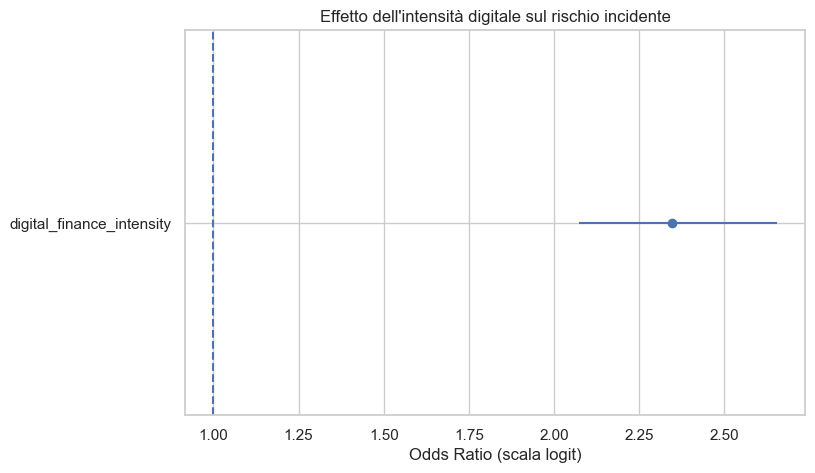

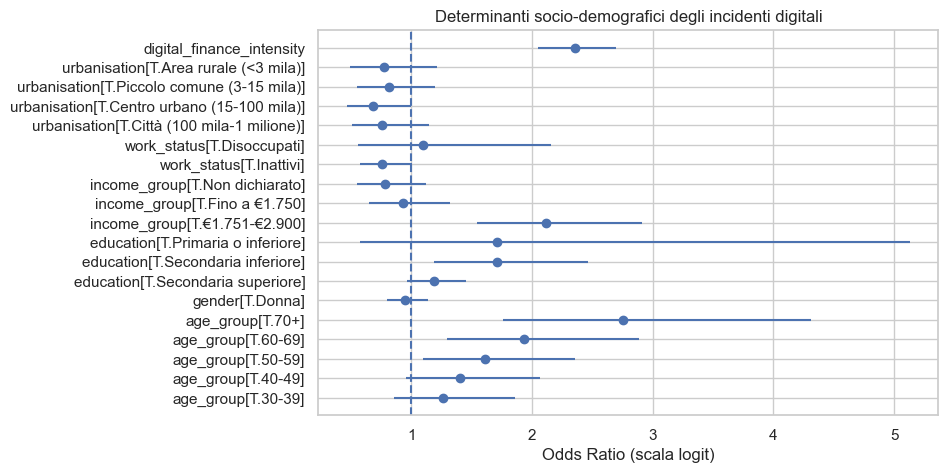

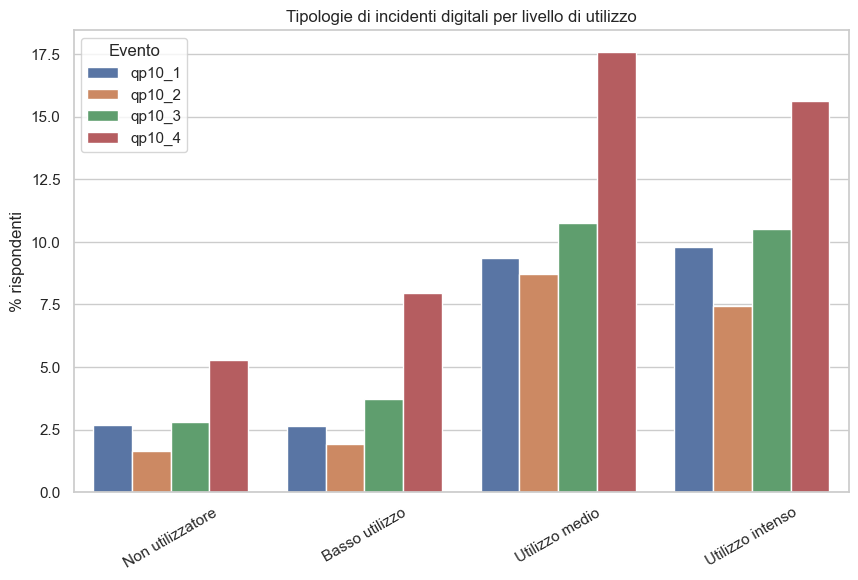

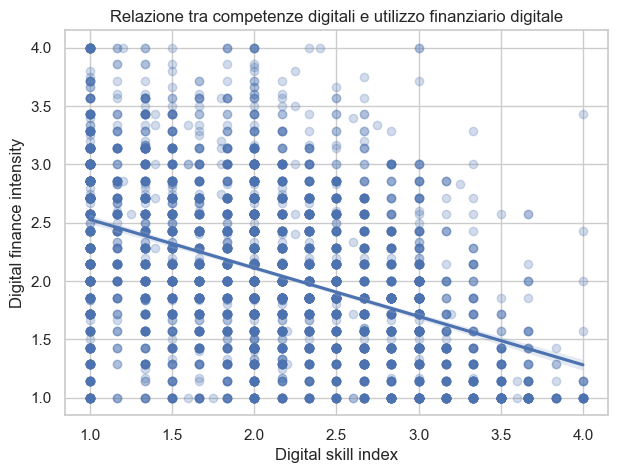

In [57]:

sns.set_theme(style="whitegrid")

# ==========================================================
# GRAFICI ANALISI DIGITAL FINANCIAL INCIDENT
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

os.makedirs("grafici_output", exist_ok=True)


sns.set_theme(style="whitegrid")


# ==========================================================
# 1. DISTRIBUZIONE DIGITAL INCIDENT
# ==========================================================

plt.figure(figsize=(6,4))

incident_dist = (
    analysis_df["digital_incident"]
    .value_counts(dropna=False)
    .rename(index={0:"Nessun incidente",1:"Incidente"})
)

sns.barplot(
    x=incident_dist.index,
    y=incident_dist.values
)

plt.title("Distribuzione degli incidenti digitali")
plt.ylabel("Numero rispondenti")
plt.xlabel("")

plt.savefig("grafici_output/distribuzione_digital_incident.png", dpi=300, bbox_inches="tight")
plt.show()



# ==========================================================
# 2. INCIDENTI PER GRUPPO DI UTILIZZO DIGITALE
# ==========================================================

incident_group = (
    analysis_df
    .groupby("digital_user_group", observed=False)
    ["digital_incident"]
    .mean()
    .mul(100)
    .reset_index()
)


plt.figure(figsize=(8,5))

sns.barplot(
    data=incident_group,
    x="digital_user_group",
    y="digital_incident"
)

plt.title(
    "Percentuale di incidenti per livello di utilizzo digitale"
)

plt.ylabel("% con almeno un incidente")
plt.xlabel("Gruppo utilizzo digitale")

plt.xticks(rotation=30)

plt.savefig("grafici_output/incidenti_per_livello_di_utilizzo_digitale.png", dpi=300, bbox_inches="tight")
plt.show()



# ==========================================================
# 3. INTENSITA' DIGITALE VS RISCHIO INCIDENTE
# ==========================================================

plt.figure(figsize=(7,5))


sns.boxplot(
    data=analysis_df,
    x="digital_incident",
    y="digital_finance_intensity"
)


plt.title(
    "Distribuzione dell'intensità digitale per presenza di incidente"
)

plt.xlabel(
    "Incidente digitale"
)

plt.ylabel(
    "Indice intensità finanziaria digitale"
)

plt.xticks(
    [0,1],
    ["No incidente","Incidente"]
)

plt.savefig("grafici_output/intensità_vs_incidente.png", dpi=300, bbox_inches="tight")
plt.show()



# ==========================================================
# 4. RISCHIO RELATIVO
# ==========================================================

risk = (
    analysis_df
    .groupby(
        "digital_user_group",
        observed=False
    )
    ["digital_incident"]
    .mean()
)


risk_relative = (
    risk / risk.iloc[0]
)


risk_relative = (
    risk_relative
    .reset_index()
    .rename(columns={
        "digital_incident":"Rischio relativo"
    })
)



plt.figure(figsize=(8,5))


sns.barplot(
    data=risk_relative,
    x="digital_user_group",
    y="Rischio relativo"
)


plt.axhline(
    1,
    linestyle="--"
)


plt.title(
    "Rischio relativo di incidente rispetto ai non utilizzatori"
)


plt.ylabel(
    "Indice rischio relativo"
)

plt.xlabel(
    ""
)

plt.xticks(rotation=30)

plt.savefig("grafici_output/rischio_relativo.png", dpi=300, bbox_inches="tight")
plt.show()



# ==========================================================
# 5. ODDS RATIO MODELLO LOGIT PRINCIPALE
# ==========================================================

def plot_odds_ratio(model, title):

    params = model.params
    conf = model.conf_int()

    odds = np.exp(params)

    errors = np.exp(conf)

    results = pd.DataFrame({
        "Variable":odds.index,
        "Odds Ratio":odds,
        "Lower":errors[0],
        "Upper":errors[1]
    })

    results = results[
        results["Variable"]!="Intercept"
    ]


    plt.figure(figsize=(8,5))


    plt.errorbar(
        results["Odds Ratio"],
        results["Variable"],
        xerr=[
            results["Odds Ratio"]-results["Lower"],
            results["Upper"]-results["Odds Ratio"]
        ],
        fmt="o"
    )


    plt.axvline(
        1,
        linestyle="--"
    )


    plt.title(title)

    plt.xlabel(
        "Odds Ratio (scala logit)"
    )

    plt.ylabel("")


    plt.savefig("grafici_output/odds_ratio_logit.png", dpi=300, bbox_inches="tight")
    plt.show()



plot_odds_ratio(
    model1,
    "Effetto dell'intensità digitale sul rischio incidente"
)



# ==========================================================
# 6. MODELLO COMPLETO: EFFETTI DEMOGRAFICI
# ==========================================================

plot_odds_ratio(
    model2,
    "Determinanti socio-demografici degli incidenti digitali"
)



# ==========================================================
# 7. TIPI DI FRODE SEPARATI
# ==========================================================

fraud_long = (
    analysis_df
    .groupby(
        "digital_user_group",
        observed=False
    )[available_incidents]
    .mean()
    .mul(100)
    .reset_index()
    .melt(
        id_vars="digital_user_group",
        var_name="Tipo incidente",
        value_name="Percentuale"
    )
)



plt.figure(figsize=(10,6))


sns.barplot(
    data=fraud_long,
    x="digital_user_group",
    y="Percentuale",
    hue="Tipo incidente"
)


plt.title(
    "Tipologie di incidenti digitali per livello di utilizzo"
)


plt.ylabel(
    "% rispondenti"
)

plt.xlabel(
    ""
)

plt.xticks(rotation=30)

plt.legend(
    title="Evento"
)

plt.savefig("grafici_output/tipi_frode.png", dpi=300, bbox_inches="tight")
plt.show()



# ==========================================================
# 8. INTENSITA' DIGITALE E DIGITAL SKILL
# ==========================================================

plt.figure(figsize=(7,5))


sns.regplot(
    data=analysis_df,
    x="digital_skill",
    y="digital_finance_intensity",
    scatter_kws={"alpha":0.25}
)


plt.title(
    "Relazione tra competenze digitali e utilizzo finanziario digitale"
)


plt.xlabel(
    "Digital skill index"
)

plt.ylabel(
    "Digital finance intensity"
)

plt.savefig("grafici_output/intensità_vs_skills.png", dpi=300, bbox_inches="tight")
plt.show()